In [1]:
!git clone https://github.com/lanadanolic/custom-hybrid-cnn-for-cifar10.git

Cloning into 'custom-hybrid-cnn-for-cifar10'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 53 (delta 19), reused 33 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 13.30 KiB | 3.32 MiB/s, done.
Resolving deltas: 100% (19/19), done.


In [2]:
%cd /content/custom-hybrid-cnn-for-cifar10

/content/custom-hybrid-cnn-for-cifar10


In [3]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from sklearn.model_selection import train_test_split

In [4]:
print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
PROJECT_DIR = Path.cwd()

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

print("Project directory:", PROJECT_DIR)

Project directory: /content/custom-hybrid-cnn-for-cifar10


In [6]:
from src.models import (
    build_standard_cnn,
    build_depthwise_cnn,
    build_dilated_cnn,
    build_hybrid_cnn
)

from src.training import (
    compile_model,
    train_model
)

from src.evaluation import (
    plot_history,
    evaluate_model
)

In [7]:
(x_train_original, y_train_original), (x_test, y_test) = (
    keras.datasets.cifar10.load_data()
)

y_train_original = y_train_original.squeeze()
y_test = y_test.squeeze()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 723s 4us/step


In [8]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [9]:
SEED = 42

x_train, x_val, y_train, y_val = train_test_split(
    x_train_original,
    y_train_original,
    test_size=5000,
    random_state=SEED,
    stratify=y_train_original
)

In [10]:
print("Train:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (45000, 32, 32, 3) (45000,)
Validation: (5000, 32, 32, 3) (5000,)
Test: (10000, 32, 32, 3) (10000,)


In [11]:
x_train = x_train.astype("float32") / 255.0
x_val = x_val.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [13]:
standard_model = build_standard_cnn()

standard_model.summary()

Model: "StandardCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 48)     │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 32, 32, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 96)     │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 192)      │       165,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 192)      │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 8, 8, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 192)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,450 (880.66 KB)

 Trainable params: 224,714 (877.79 KB)

 Non-trainable params: 736 (2.88 KB)

In [14]:
compile_model(standard_model)

In [15]:
standard_history, standard_training_time = train_model(
    standard_model,
    "StandardCNN",
    x_train,
    y_train,
    x_val,
    y_val
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.4568 - loss: 1.4789 - val_accuracy: 0.2918 - val_loss: 2.4315 - learning_rate: 0.0010
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.5752 - loss: 1.1887 - val_accuracy: 0.5822 - val_loss: 1.1807 - learning_rate: 0.0010
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6212 - loss: 1.0622 - val_accuracy: 0.5464 - val_loss: 1.2901 - learning_rate: 0.0010
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6533 - loss: 0.9816 - val_accuracy: 0.5606 - val_loss: 1.3969 - learning_rate: 0.0010
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6706 - loss: 0.9286 - val_accuracy: 0.5276 - val_loss: 1.5036 - learning_rate: 0.0010
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6946 - loss: 0.8754 - val_accuracy: 0.5042 - val_loss: 1.7644 - learning_rate: 0.0010
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.7198 - lo

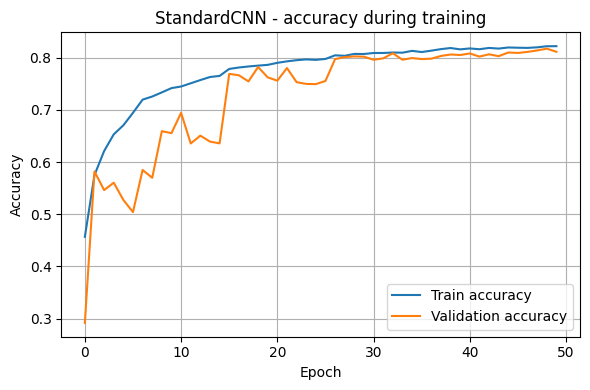

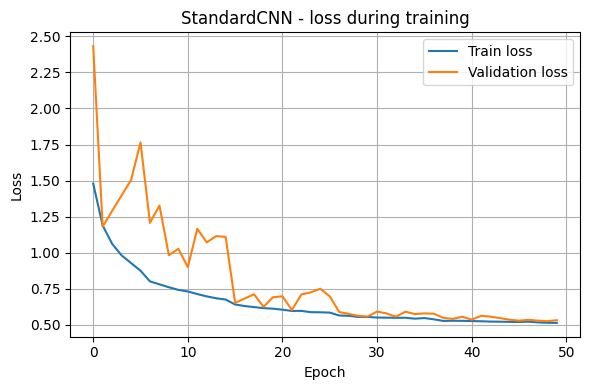

In [17]:
plot_history(
    standard_history,
    "StandardCNN"
)


StandardCNN
Test loss: 0.5455
Accuracy: 0.8137 (81.37%)
Precision: 0.8150
Recall: 0.8137
F1-score: 0.8135
Number of parameters: 225450
Training time: 490.8715 s
Prediction time per image: 0.0835 ms

Classification report:
              precision    recall  f1-score   support

    airplane     0.7709    0.8650    0.8153      1000
  automobile     0.8877    0.9330    0.9098      1000
        bird     0.7195    0.7360    0.7276      1000
         cat     0.6680    0.6620    0.6650      1000
        deer     0.8131    0.7830    0.7978      1000
         dog     0.7566    0.7150    0.7352      1000
        frog     0.8267    0.8780    0.8516      1000
       horse     0.8922    0.8110    0.8497      1000
        ship     0.8939    0.8930    0.8934      1000
       truck     0.9209    0.8610    0.8899      1000

    accuracy                         0.8137     10000
   macro avg     0.8150    0.8137    0.8135     10000
weighted avg     0.8150    0.8137    0.8135     10000



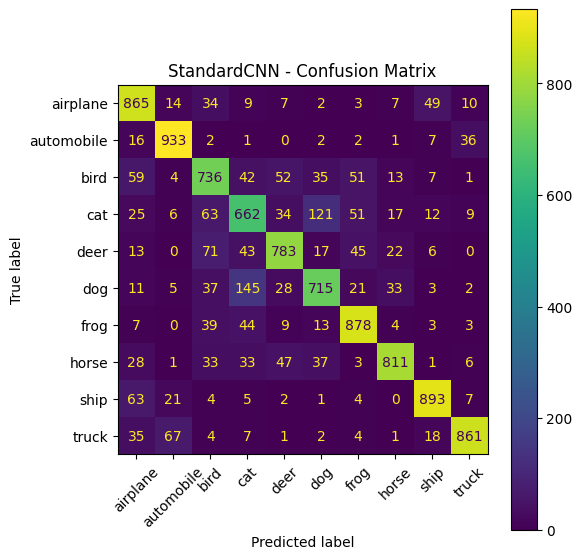

In [18]:
standard_results = evaluate_model(
    standard_model,
    "StandardCNN",
    standard_training_time,
    x_test,
    y_test,
    class_names
)

In [19]:
depthwise_model = build_depthwise_cnn()

depthwise_model.summary()

Model: "DepthwiseCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 32, 32, 32)     │           123 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 32, 32, 48)     │         1,824 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 32, 32, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 16, 16, 96)     │         5,040 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 8, 8, 192)      │        19,296 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 192)      │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 8, 8, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 192)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,685 (115.96 KB)

 Trainable params: 28,949 (113.08 KB)

 Non-trainable params: 736 (2.88 KB)

In [20]:
compile_model(depthwise_model)

In [21]:
depthwise_history, depthwise_training_time = train_model(
    depthwise_model,
    "DepthwiseCNN",
    x_train,
    y_train,
    x_val,
    y_val
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.3578 - loss: 1.7398 - val_accuracy: 0.1006 - val_loss: 2.8168 - learning_rate: 0.0010
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.4663 - loss: 1.4667 - val_accuracy: 0.4524 - val_loss: 1.4460 - learning_rate: 0.0010
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.5108 - loss: 1.3519 - val_accuracy: 0.4764 - val_loss: 1.4646 - learning_rate: 0.0010
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.5438 - loss: 1.2682 - val_accuracy: 0.4718 - val_loss: 1.5029 - learning_rate: 0.0010
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.5645 - loss: 1.2130 - val_accuracy: 0.5016 - val_loss: 1.4201 - learning_rate: 0.0010
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.5833 - loss: 1.1649 - val_accuracy: 0.5318 - val_loss: 1.3300 - learning_rate: 0.0010
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5959 - loss:

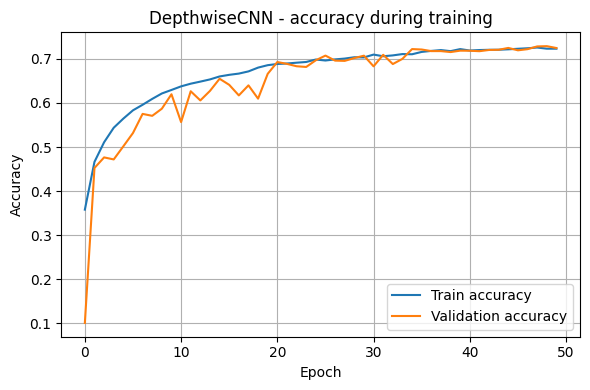

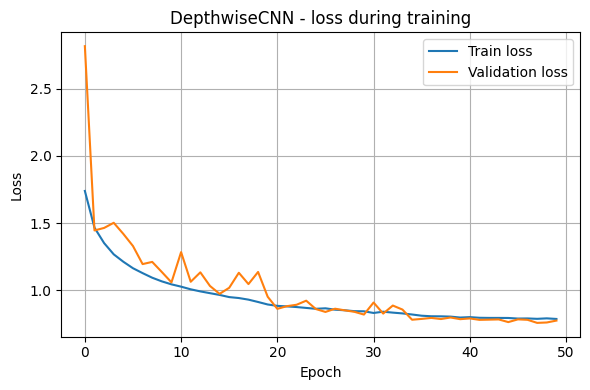

In [22]:
plot_history(
    depthwise_history,
    "DepthwiseCNN"
)

DepthwiseCNN
Test loss: 0.7642
Accuracy: 0.7339 (73.39%)
Precision: 0.7331
Recall: 0.7339
F1-score: 0.7299
Number of parameters: 29685
Training time: 437.7503 s
Prediction time per image: 0.1073 ms

Classification report:
              precision    recall  f1-score   support

    airplane     0.7041    0.7970    0.7477      1000
  automobile     0.8270    0.9080    0.8656      1000
        bird     0.6835    0.5420    0.6046      1000
         cat     0.6062    0.4710    0.5301      1000
        deer     0.6645    0.7030    0.6832      1000
         dog     0.6844    0.6440    0.6636      1000
        frog     0.6625    0.8500    0.7446      1000
       horse     0.7632    0.7830    0.7730      1000
        ship     0.8497    0.8370    0.8433      1000
       truck     0.8864    0.8040    0.8432      1000

    accuracy                         0.7339     10000
   macro avg     0.7331    0.7339    0.7299     10000
weighted avg     0.7331    0.7339    0.7299     10000



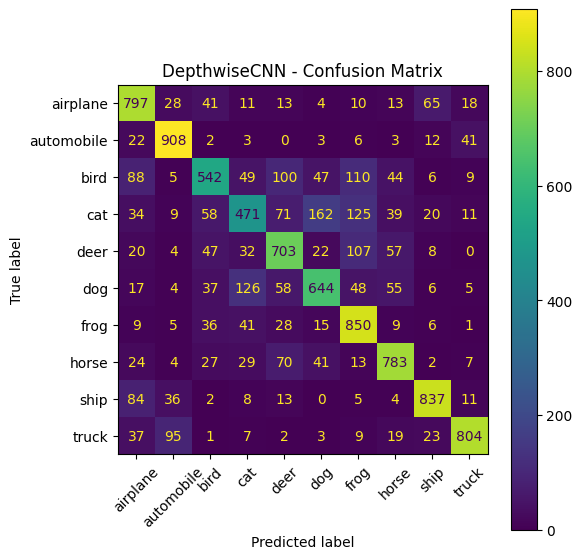

In [23]:
depthwise_results = evaluate_model(
    depthwise_model,
    "DepthwiseCNN",
    depthwise_training_time,
    x_test,
    y_test,
    class_names
)

In [24]:
dilated_model = build_dilated_cnn()

dilated_model.summary()


Model: "DilatedCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 48)     │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 32, 32, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 96)     │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_14 (ReLU)                 │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 192)      │       165,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 192)      │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_15 (ReLU)                 │ (None, 8, 8, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 192)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,450 (880.66 KB)

 Trainable params: 224,714 (877.79 KB)

 Non-trainable params: 736 (2.88 KB)

In [25]:
compile_model(dilated_model)

In [26]:
dilated_history, dilated_training_time = train_model(
    dilated_model,
    "DilatedCNN",
    x_train,
    y_train,
    x_val,
    y_val
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.4733 - loss: 1.4448 - val_accuracy: 0.2184 - val_loss: 2.9764 - learning_rate: 0.0010
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.5891 - loss: 1.1520 - val_accuracy: 0.5608 - val_loss: 1.2135 - learning_rate: 0.0010
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.6314 - loss: 1.0362 - val_accuracy: 0.5596 - val_loss: 1.2812 - learning_rate: 0.0010
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.6614 - loss: 0.9585 - val_accuracy: 0.6020 - val_loss: 1.1908 - learning_rate: 0.0010
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.6790 - loss: 0.9052 - val_accuracy: 0.6100 - val_loss: 1.2282 - learning_rate: 0.0010
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.6973 - loss: 0.8615 - val_accuracy: 0.6192 - val_loss: 1.1255 - learning_rate: 0.0010
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.7121 - l

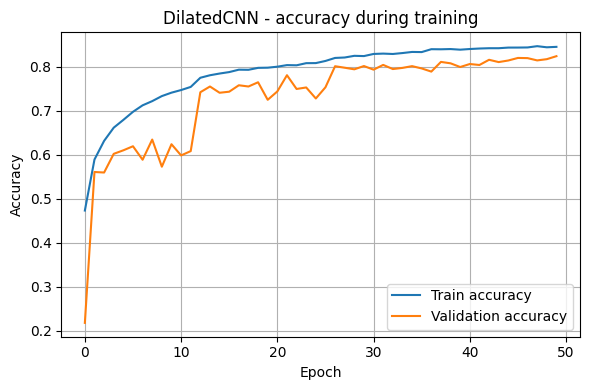

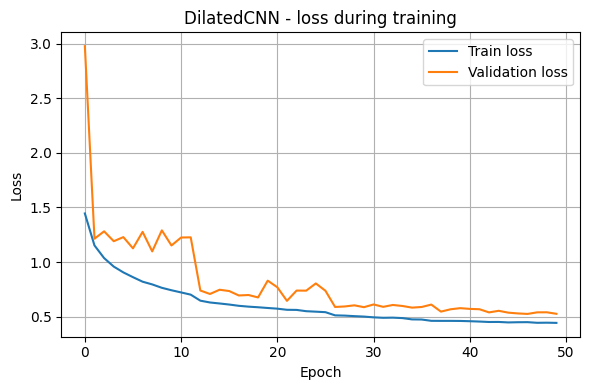

In [27]:
plot_history(
    dilated_history,
    "DilatedCNN"
)

DilatedCNN
Test loss: 0.5686
Accuracy: 0.8079 (80.79%)
Precision: 0.8075
Recall: 0.8079
F1-score: 0.8062
Number of parameters: 225450
Training time: 667.6584 s
Prediction time per image: 0.1586 ms

Classification report:
              precision    recall  f1-score   support

    airplane     0.7746    0.8830    0.8252      1000
  automobile     0.8510    0.9370    0.8920      1000
        bird     0.7719    0.7140    0.7418      1000
         cat     0.6826    0.6130    0.6459      1000
        deer     0.8345    0.7460    0.7878      1000
         dog     0.7278    0.7140    0.7208      1000
        frog     0.7927    0.8910    0.8390      1000
       horse     0.8315    0.8490    0.8402      1000
        ship     0.9059    0.8660    0.8855      1000
       truck     0.9021    0.8660    0.8837      1000

    accuracy                         0.8079     10000
   macro avg     0.8075    0.8079    0.8062     10000
weighted avg     0.8075    0.8079    0.8062     10000



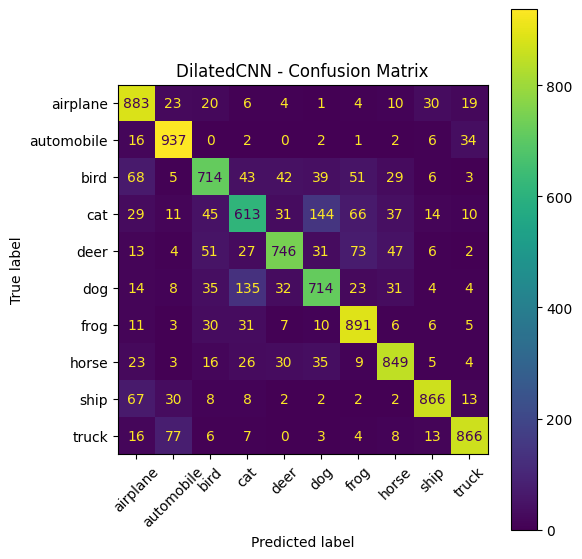

In [28]:
dilated_results = evaluate_model(
    dilated_model,
    "DilatedCNN",
    dilated_training_time,
    x_test,
    y_test,
    class_names
)

In [29]:
hybrid_model = build_hybrid_cnn(
    dilation_rate=2
)

hybrid_model.summary()

Model: "HybridCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 32, 32, 3) │          0 │ input_layer_8[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 32, 32,    │        297 │ sequential_4[0][… │
│                     │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_4  │ (None, 32, 32,    │         60 │ sequential_4[0][… │
│ (SeparableConv2D)   │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 32, 32,    │        297 │ sequential_4[0][… │
│                     │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         44 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         44 │ separable_conv2d… │
│ (BatchNormalizatio… │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         44 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_16 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_17 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_18 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ re_lu_16[0][0],   │
│ (Concatenate)       │ 33)               │            │ re_lu_17[0][0],   │
│                     │                   │            │ re_lu_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 32, 32,    │      1,056 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 32, 32,    │      4,608 │ re_lu_19[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 212,204 (828.92 KB)

 Trainable params: 210,730 (823.16 KB)

 Non-trainable params: 1,474 (5.76 KB)

In [30]:
compile_model(hybrid_model)

In [31]:
hybrid_history, hybrid_training_time = train_model(
    hybrid_model,
    "HybridCNN",
    x_train,
    y_train,
    x_val,
    y_val
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 0.4749 - loss: 1.4353 - val_accuracy: 0.2282 - val_loss: 2.2556 - learning_rate: 0.0010
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.6119 - loss: 1.0803 - val_accuracy: 0.4018 - val_loss: 1.8189 - learning_rate: 0.0010
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.6644 - loss: 0.9430 - val_accuracy: 0.4096 - val_loss: 2.1956 - learning_rate: 0.0010
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.7001 - loss: 0.8518 - val_accuracy: 0.5822 - val_loss: 1.2031 - learning_rate: 0.0010
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.7256 - loss: 0.7811 - val_accuracy: 0.5320 - val_loss: 1.4822 - learning_rate: 0.0010
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.7477 - loss: 0.7237 - val_accuracy: 0.5048 - val_loss: 1.7602 - learning_rate: 0.0010
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.7644 - l

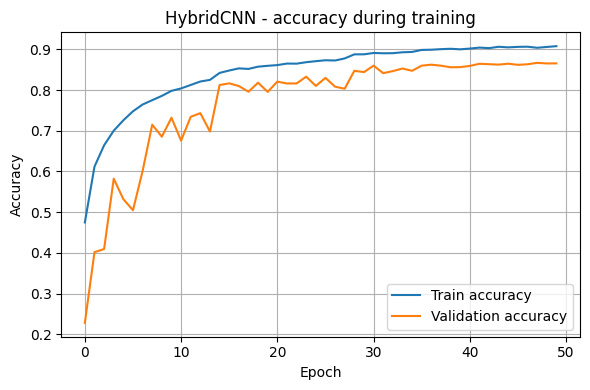

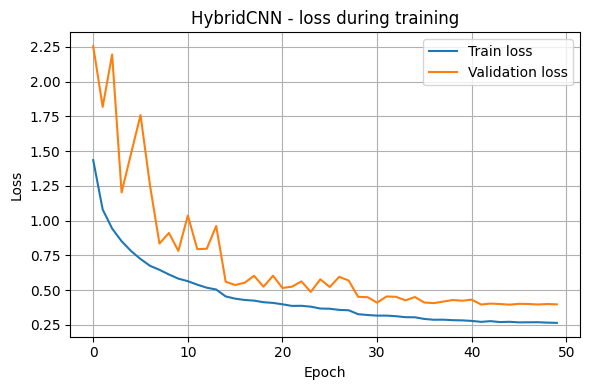

In [32]:
plot_history(
    hybrid_history,
    "HybridCNN"
)

HybridCNN
Test loss: 0.4182
Accuracy: 0.8618 (86.18%)
Precision: 0.8624
Recall: 0.8618
F1-score: 0.8615
Number of parameters: 212204
Training time: 1117.9304 s
Prediction time per image: 0.1285 ms

Classification report:
              precision    recall  f1-score   support

    airplane     0.8459    0.8840    0.8645      1000
  automobile     0.9130    0.9550    0.9335      1000
        bird     0.8107    0.8180    0.8143      1000
         cat     0.7479    0.7240    0.7358      1000
        deer     0.8338    0.8430    0.8384      1000
         dog     0.8188    0.7910    0.8047      1000
        frog     0.8585    0.9340    0.8946      1000
       horse     0.9421    0.8460    0.8915      1000
        ship     0.9463    0.8990    0.9221      1000
       truck     0.9068    0.9240    0.9153      1000

    accuracy                         0.8618     10000
   macro avg     0.8624    0.8618    0.8615     10000
weighted avg     0.8624    0.8618    0.8615     10000



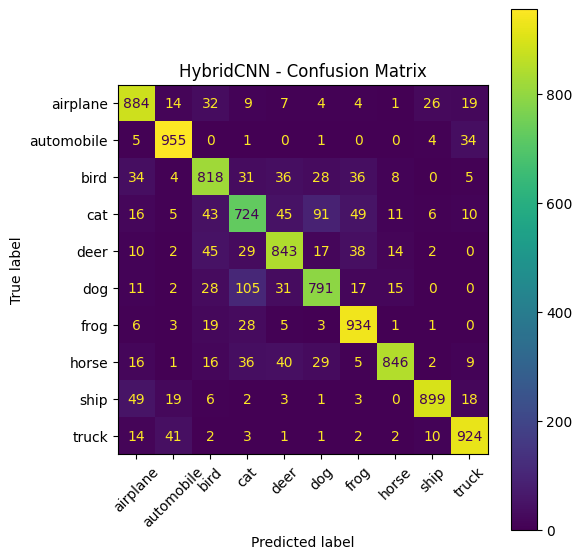

In [33]:
hybrid_results = evaluate_model(
    hybrid_model,
    "HybridCNN",
    hybrid_training_time,
    x_test,
    y_test,
    class_names
)

In [34]:
results_df = pd.DataFrame([
    standard_results,
    depthwise_results,
    dilated_results,
    hybrid_results
])

results_df

,Model,Test loss,Accuracy,Precision,Recall,F1-score,Parameters,Training time (s),Prediction time per image (ms)
0,StandardCNN,0.545510,0.8137,0.814951,0.8137,0.813530,225450,490.871481,0.083544
1,DepthwiseCNN,0.764191,0.7339,0.733137,0.7339,0.729880,29685,437.750312,0.107317
2,DilatedCNN,0.568586,0.8079,0.807459,0.8079,0.806187,225450,667.658404,0.158579
3,HybridCNN,0.418178,0.8618,0.862388,0.8618,0.861471,212204,1117.930401,0.128530


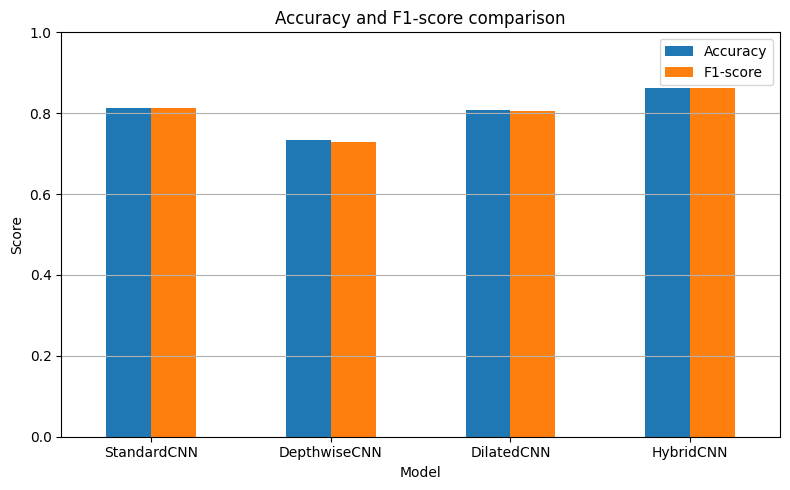

In [35]:
# comparison of classification performance

performance_df = results_df.set_index("Model")[
    ["Accuracy", "F1-score"]
]

performance_df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Accuracy and F1-score comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

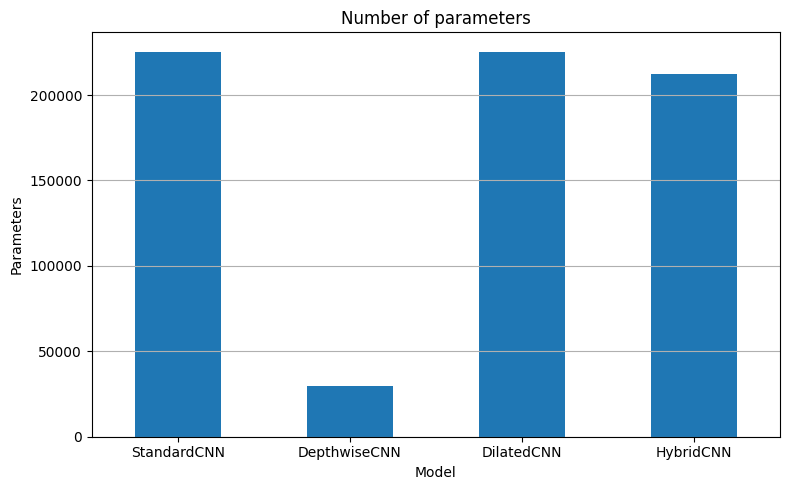

In [36]:
# comparison of model size

results_df.plot(
    x="Model",
    y="Parameters",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Number of parameters")
plt.ylabel("Parameters")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

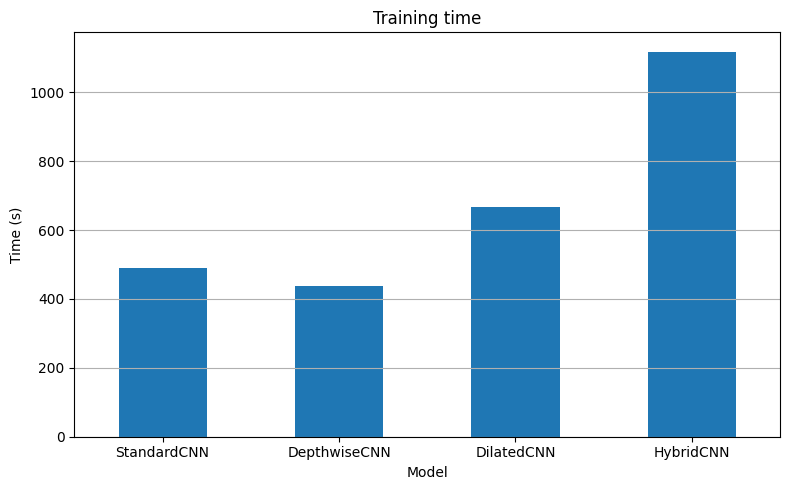

In [37]:
# comparison of training time

results_df.plot(
    x="Model",
    y="Training time (s)",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Training time")
plt.ylabel("Time (s)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

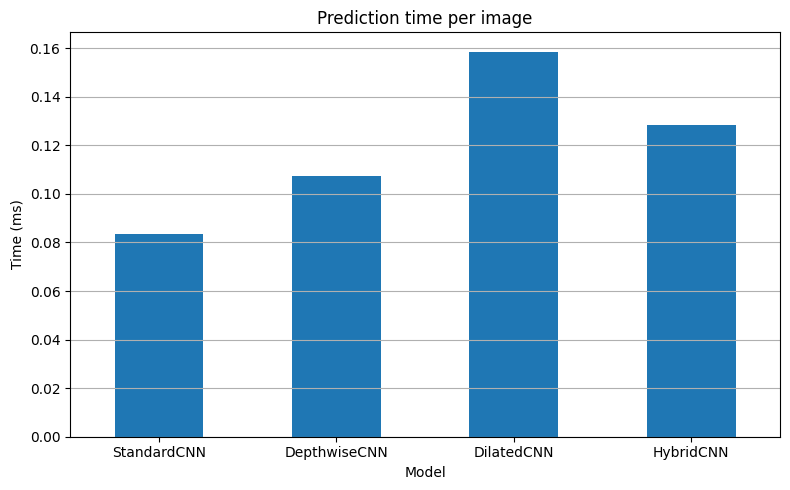

In [38]:
# comparison of prediction time

results_df.plot(
    x="Model",
    y="Prediction time per image (ms)",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Prediction time per image")
plt.ylabel("Time (ms)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()